In [3]:
from pickleshare import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score,confusion_matrix, ConfusionMatrixDisplay
import joblib
!pip install -q streamlit
import pickle
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.9 MB/s eta 0:00:00


In [4]:
df = pd.read_csv('/content/titanic.csv')

In [5]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
x = df.drop(['Survived', 'PassengerId', 'Ticket', 'Name'], axis=1)
y = df['Survived']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state= 42)

In [11]:
cat_cols = ['Embarked', 'Cabin', 'Sex']
num_cols = ['Age', 'Pclass', 'Parch', 'Fare', 'SibSp']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ],
    remainder='drop'
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(solver='liblinear'))
])

In [12]:
pipeline_model = final_pipeline.fit(x_train, y_train)

In [13]:
predicition = pipeline_model.predict(x_test)

In [14]:
accuracy = accuracy_score(y_test, predicition)
print(accuracy)

0.8212290502793296


In [15]:
precision = precision_score(y_test, predicition)
print(precision)

0.8


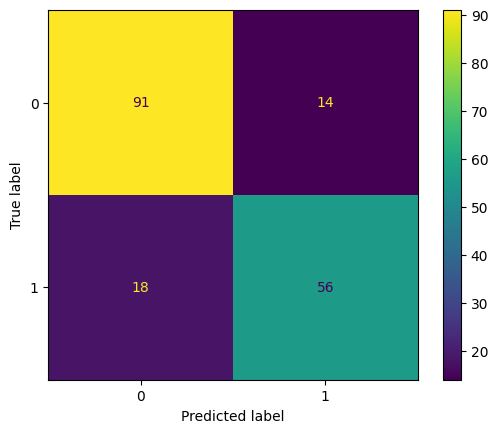

In [16]:

ConfusionMatrixDisplay.from_predictions(y_test, predicition)

In [21]:
with open("titanic_model.pkl", "wb") as f:
    pickle.dump(pipeline_model, f)


In [18]:
%%writefile app.py

Writing app.py


In [23]:
with open("titanic_model.pkl", "rb") as f:
    model = pickle.load(f)
st.title("Titanic Survival Prediction")

st.write("Enter Passenger details")
pclass = st.selectbox("Passenger Class", [1,2,3])
sex = st.selectbox("Sex", ["Female","Male"])
age = st.slider("Age", 1, 80, 25)
sex_val = 0 if sex=="Female" else 1
if st.button("Predict Survival"):
 features = np.array([[pclass, sex_val, age]])
 prediction = model.predict(features)

 if prediction[0] == 1:
    st.success("Passenger is likely to SURVIVE")
 else:
    st.error("Passenger is NOT likely to survive")

2026-03-18 10:43:20.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 10:43:20.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 10:43:20.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 10:43:20.547 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 10:43:20.547 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 10:43:20.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 10:43:20.550 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 10:43:20.551 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [25]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.221.238:8501

  Stopping...
  Stopping...
